# **Лабораторная работа 3**
# Исследование нелинейной динамики сердечного ритма

## Исходные данные

In [ ]:
!pip install nolds

In [1]:
import pandas as pd
import numpy as np

data = pd.read_csv("1_f.csv", header=None)
rr = data.iloc[:,0].values.astype(float)

## Расчёт показателя Херста

Показатель Херста – степень долговременной устойчивости процессов, протекающих
в биомедицинском сигнале

#### H - показатель Херста
#### Если H > 0.5 → персистентность
#### Если H = 0.5 → случайный процесс
#### Если H < 0.5 → анти-персистентность

In [ ]:
def hurst_rs(series, min_power=4):
    series = np.asarray(series, dtype=float)
    series = series - series.mean()
    N = series.size
    max_power = int(np.floor(np.log2(N)))

    sizes = []
    rs_values = []

    for power in range(min_power, max_power + 1):
        size = 2 ** power
        n_blocks = N // size
        if n_blocks < 2:
            continue

        block_rs = []
        for i in range(n_blocks):
            block = series[i * size:(i + 1) * size]
            X = np.cumsum(block - block.mean())
            R = X.max() - X.min()
            S = np.std(block, ddof=0)
            if S > 0:
                block_rs.append(R / S)

        if block_rs:
            sizes.append(size)
            rs_values.append(np.mean(block_rs))

    if len(sizes) < 2:
        return np.nan

    log_sizes = np.log(sizes)
    log_rs = np.log(rs_values)
    H, _ = np.polyfit(log_sizes, log_rs, 1)
    return H

H = hurst_rs(rr)
print('H =', H)

H = 0.8391286310171107


## Расчёт показателя флуктуации (DFA)

DFA (Detrended Fluctuation Analysis) – показатель затухания спектральной плотности мощности,
определяемый на основе спектральных преобразований

#### α - показатель флуктуации (DFA)
#### α ≈ 0.5 → белый шум
#### α ≈ 1 → фрактальная структура
#### α > 1 → сильная корреляция

In [ ]:
def dfa(series, min_scale=4, max_fraction=0.25, n_scales=20):
    series = np.asarray(series, dtype=float)
    series = series - series.mean()
    Y = np.cumsum(series)
    N = Y.size

    max_scale = max(min_scale + 1, int(np.floor(N * max_fraction)))
    scales = np.unique(np.floor(np.logspace(np.log10(min_scale), np.log10(max_scale), n_scales)).astype(int))

    F = []
    valid_scales = []

    for s in scales:
        n_segments = N // s
        if n_segments < 2:
            continue

        variances = []
        for i in range(n_segments):
            segment = Y[i * s:(i + 1) * s]
            t = np.arange(s)
            coeffs = np.polyfit(t, segment, 1)
            trend = np.polyval(coeffs, t)
            detrended = segment - trend
            variances.append(np.mean(detrended ** 2))

        if variances:
            valid_scales.append(s)
            F.append(np.sqrt(np.mean(variances)))

    if len(valid_scales) < 2:
        return np.nan

    log_scales = np.log(valid_scales)
    log_F = np.log(F)
    alpha, _ = np.polyfit(log_scales, log_F, 1)
    return alpha

alpha = dfa(rr)
print('α =', alpha)

α = 1.4833086678334828


## Сравнение с библиотекой nolds

In [23]:
import nolds

hurst_lib = nolds.hurst_rs(rr)
dfa_lib = nolds.dfa(rr)

print('H =', hurst_lib)
print('α =', dfa_lib)

H = 0.7635185553447289
α = 0.975032554714326


In [17]:
results = pd.DataFrame({
    "Метод": ["Своя реализация", "Библиотека nolds"],
    "Hurst": [H, hurst_lib],
    "DFA": [alpha, dfa_lib]
})

results

,Метод,Hurst,DFA
0,Своя реализация,0.839129,1.483309
1,Библиотека nolds,0.760415,0.975033


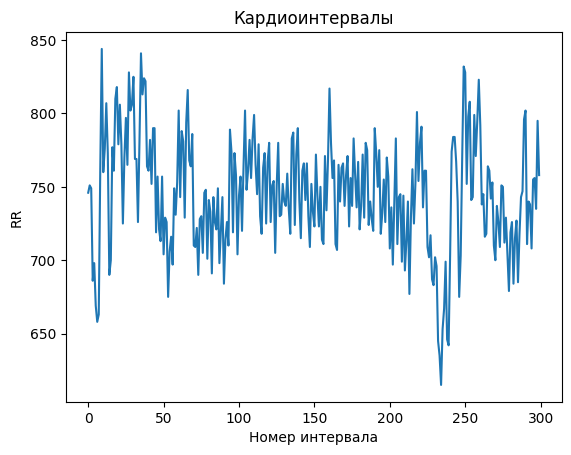

In [16]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(rr)
plt.title("Кардиоинтервалы")
plt.xlabel("Номер интервала")
plt.ylabel("RR")
plt.show()

Собственная реализация показателя Херста (0.839) близка к результату библиотеки nolds (0.760), что подтверждает работоспособность алгоритма.

Для DFA получено более заметное расхождение: 1.483 при собственной реализации и 0.975 при использовании библиотеки.
Это различие связано с разным выбором масштабов анализа и методами усреднения флуктуаций в алгоритмах.

Библиотечная реализация считается более стабильной, но оба подхода указывают на наличие коррелированной структуры во временном ряде.